In [1]:
import pickle as pkl
import pandas as pd
import numpy as np
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from src import util_analysis 
from scipy import stats 


# Compare 50Hz model to main feature-gain model per condition

## Analysis:
For each background condition, average across SNRs and plot difference in accuracy, a,  between both:  $a_{\text{main model}} - a_{\text{50 Hz cutoff}}$

### Get data

,model,snr,azim_delta,elev_delta,accuracy,accuracy_sem,confusions,confusions_sem,group,background_condition,experiment
0,50Hz cutoff,-9,0,0,0.100922,0.011290,0.282531,0.045698,50Hz cutoff,0 azim delta 0 elev delta,Threshold
1,50Hz cutoff,-9,0,10,0.101691,0.011760,0.277920,0.044163,50Hz cutoff,0 azim delta 10 elev delta,Threshold
2,50Hz cutoff,-9,0,60,0.117572,0.014389,0.237449,0.040025,50Hz cutoff,0 azim delta 60 elev delta,Threshold
3,50Hz cutoff,-9,10,0,0.141393,0.012493,0.233350,0.041276,50Hz cutoff,10 azim delta 0 elev delta,Threshold
4,50Hz cutoff,-9,60,0,0.268186,0.007941,0.040471,0.008669,50Hz cutoff,60 azim delta 0 elev delta,Threshold
...,...,...,...,...,...,...,...,...,...,...,...
475,Human (N=33),6,0,0,0.738981,0.023420,0.009470,0.003961,Human (N=33),0 azim delta 0 elev delta,Threshold
476,Human (N=33),6,0,10,0.770633,0.021301,0.011364,0.004261,Human (N=33),0 azim delta 10 elev delta,Threshold
477,Human (N=33),6,0,60,0.790152,0.019521,0.013258,0.004517,Human (N=33),0 azim delta 60 elev delta,Threshold
478,Human (N=33),6,10,0,0.769112,0.021340,0.011364,0.004261,Human (N=33),10 azim delta 0 elev delta,Threshold


In [76]:
### Import pre-formated data 

results_dir = Path('final_results_dir')

# diotic SWC 
diotic_results = pd.read_pickle(results_dir / "df_for_stats_and_summary_2024_SWC_diotic_conditions_humans_N-195_models_v10_w_control_50Hz_ECDF_models.pdpkl")
diotic_results['experiment'] = 'Diotic'

# Popham SWC
popham_results = pd.read_pickle(results_dir / "df_for_stats_2024_SWC_popham_conditions_humans_N-90_models_v10_w_control_50Hz_ECDF_models.pdpkl")
popham_results.loc[popham_results.group.str.contains("Human"), 'model'] = popham_results.loc[popham_results.group.str.contains("Human"), 'group']
popham_results['snr'] = 0 # add snr column to match diotic_results
popham_conds_to_keep = ['Harmonic_target_Harmonic_distractor',
                        'Harmonic_target_No Distractor_distractor',
                        'Inharmonic_target_Inharmonic_distractor',
                        'Inharmonic_target_No Distractor_distractor',
                        'Whispered_target_No Distractor_distractor',
                        'Whispered_target_Whispered_distractor']

popham_results = popham_results[popham_results['background_condition'].isin(popham_conds_to_keep)].reset_index(drop=True)
popham_results['experiment'] = 'Harmonicity'
# threshold results 
threshold_results = pd.read_pickle(results_dir / "df_for_stats_and_summary_2024_thresholds_humans_N-33_models_v10_w_control_50Hz_ECDF_models.pdpkl")
threshold_results['background_condition'] = threshold_results['azim_delta'].astype('str') + ' azim delta ' + threshold_results['elev_delta'].astype('str') + ' elev delta' 
threshold_results['experiment'] = 'Threshold'
threshold_results.rename(columns={'accuracy_sem': 'acc_sem', 'confusions_sem': 'conf_sem'}, inplace=True)

# Spotlight results 
spotlight_results = pd.read_pickle(results_dir / "df_for_stats_and_summary_2024_spotlight_humans_N-28_models_v10_w_control_50Hz_ECDF_models.pdpkl")
spotlight_results['snr'] = 0 
spotlight_results['background_condition'] = spotlight_results['target_azim'].astype('str') + ' target azim ' + spotlight_results['azim_delta'].astype('str') + ' azim delta'
spotlight_results['experiment'] = 'Spotlight'
spotlight_results.rename(columns={'accuracy_sem': 'acc_sem', 'confusions_sem': 'conf_sem'}, inplace=True)



In [77]:
diotic_results.model.value_counts()

model
Human (N=195)                             56
word_task_v10_4MGB_ln_first_arch_1        56
word_task_v10_4MGB_ln_first_arch_10       56
word_task_v10_4MGB_ln_first_arch_12       56
word_task_v10_4MGB_ln_first_arch_2        56
word_task_v10_4MGB_ln_first_arch_4        56
word_task_v10_4MGB_ln_first_arch_6        56
word_task_v10_4MGB_ln_first_arch_7        56
word_task_v10_4MGB_ln_first_arch_8        56
word_task_v10_4MGB_ln_first_arch_9        56
word_task_v10_main_feature_gain_config    56
word_task_early_only_v10                  56
word_task_half_co_loc_v09_50Hz_cutoff     56
word_task_late_only_v10                   56
word_task_v10_backbone_word_config        56
word_task_v10_control_no_attn             56
Name: count, dtype: int64

In [78]:
popham_results.model.value_counts()

model
Humans (N = 90)                           6
word_task_v10_4MGB_ln_first_arch_1        6
word_task_v10_4MGB_ln_first_arch_10       6
word_task_v10_4MGB_ln_first_arch_12       6
word_task_v10_4MGB_ln_first_arch_2        6
word_task_v10_4MGB_ln_first_arch_4        6
word_task_v10_4MGB_ln_first_arch_6        6
word_task_v10_4MGB_ln_first_arch_7        6
word_task_v10_4MGB_ln_first_arch_8        6
word_task_v10_4MGB_ln_first_arch_9        6
word_task_v10_main_feature_gain_config    6
Early-only                                6
50Hz cutoff                               6
Late-only                                 6
Computed-gain model                       6
Baseline CNN                              6
Name: count, dtype: int64

In [79]:
threshold_results.model.value_counts()

model
50Hz cutoff             30
Baseline CNN            30
Computed-gain model     30
Early-only              30
Feature-gain alt v1     30
Feature-gain alt v10    30
Feature-gain alt v12    30
Feature-gain alt v2     30
Feature-gain alt v4     30
Feature-gain alt v6     30
Feature-gain alt v7     30
Feature-gain alt v8     30
Feature-gain alt v9     30
Feature-gain main       30
Late-only               30
Human (N=33)            30
Name: count, dtype: int64

In [80]:
spotlight_results.model.value_counts()

model
Humans (N=28)                             8
word_task_early_only_v10                  8
word_task_half_co_loc_v09_50Hz_cutoff     8
word_task_late_only_v10                   8
word_task_v10_4MGB_ln_first_arch_1        8
word_task_v10_4MGB_ln_first_arch_10       8
word_task_v10_4MGB_ln_first_arch_12       8
word_task_v10_4MGB_ln_first_arch_2        8
word_task_v10_4MGB_ln_first_arch_4        8
word_task_v10_4MGB_ln_first_arch_6        8
word_task_v10_4MGB_ln_first_arch_7        8
word_task_v10_4MGB_ln_first_arch_8        8
word_task_v10_4MGB_ln_first_arch_9        8
word_task_v10_backbone_word_config        8
word_task_v10_control_no_attn             8
word_task_v10_main_feature_gain_config    8
Name: count, dtype: int64

In [82]:
combined_results = pd.concat([diotic_results, popham_results, threshold_results, spotlight_results ], axis=0) # spotlight_results
## update model names for comparison 

# combined_results = combined_results[combined_results.model.str.contains('main|50Hz')].copy()
# combined_results.loc[combined_results['model'].str.contains("50Hz"), ['model', 'group']] = '50Hz cutoff'


In [83]:
combined_results

,group,snr,background_condition,accuracy,acc_sem,confusions,conf_sem,N,model,experiment,azim_delta,elev_delta,target_azim
0,Human (N=195),-9,1-talker,0.317094,0.019581,0.315385,0.020614,195.0,Human (N=195),Diotic,NaN,NaN,NaN
1,Human (N=195),-9,2-talker,0.066667,0.009281,0.467949,0.019008,195.0,Human (N=195),Diotic,NaN,NaN,NaN
2,Human (N=195),-9,4-talker,0.037607,0.006724,0.110684,0.011536,195.0,Human (N=195),Diotic,NaN,NaN,NaN
3,Human (N=195),-9,babble,0.035897,0.006551,0.005128,0.002544,195.0,Human (N=195),Diotic,NaN,NaN,NaN
4,Human (N=195),-9,music,0.458974,0.019222,0.005128,0.002544,195.0,Human (N=195),Diotic,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,Feature-gain Model,0,0 target azim 90 azim delta,0.711578,0.007251,0.001537,0.000627,NaN,word_task_v10_main_feature_gain_config,Spotlight,90.0,NaN,0.0
124,Feature-gain Model,0,90 target azim 0 azim delta,0.492828,0.008003,0.112961,0.005067,NaN,word_task_v10_main_feature_gain_config,Spotlight,0.0,NaN,90.0
125,Feature-gain Model,0,90 target azim 10 azim delta,0.492828,0.008003,0.109631,0.005001,NaN,word_task_v10_main_feature_gain_config,Spotlight,10.0,NaN,90.0
126,Feature-gain Model,0,90 target azim 30 azim delta,0.515881,0.007999,0.093750,0.004666,NaN,word_task_v10_main_feature_gain_config,Spotlight,30.0,NaN,90.0


In [85]:
combined_results.group.value_counts()

group
Feature-gain Model     1000
Early-only              100
50Hz cutoff             100
Late-only               100
Computed-gain model     100
Baseline CNN            100
Human (N=195)            56
Human (N=33)             30
Humans (N=28)             8
Humans (N = 90)           6
Name: count, dtype: int64

In [86]:
## Get condition dict for colors in baplot

experiment_conditions = {exp_key: combined_results[combined_results['experiment'] == exp_key]['background_condition'].unique() for exp_key in combined_results['experiment'].unique()}

condition_to_experiment = {}
for exp_key in experiment_conditions:
    for cond in experiment_conditions[exp_key]:
        condition_to_experiment[cond] = exp_key

In [87]:
# summary = combined_results.groupby(['group', 'background_condition']).agg({"accuracy": "mean", "confusions":"mean"}).reset_index()
# summary['experiment'] = summary['background_condition'].map(condition_to_experiment)


In [107]:
 human_results.experiment.unique()

array(['Threshold', 'Diotic', 'Spotlight', 'Harmonicity'], dtype=object)

Feature-gain Model
Early-only
Late-only
Baseline CNN
50Hz cutoff
Computed-gain model


/tmp/ipykernel_267229/1386424568.py:68: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fba_to_plot['snr_condition_str'] = fba_to_plot['snr'].astype(str) + ' dB ' + fba_to_plot['background_condition']
/tmp/ipykernel_267229/1386424568.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fba_to_plot['group'] = 'Feature-gain Model'


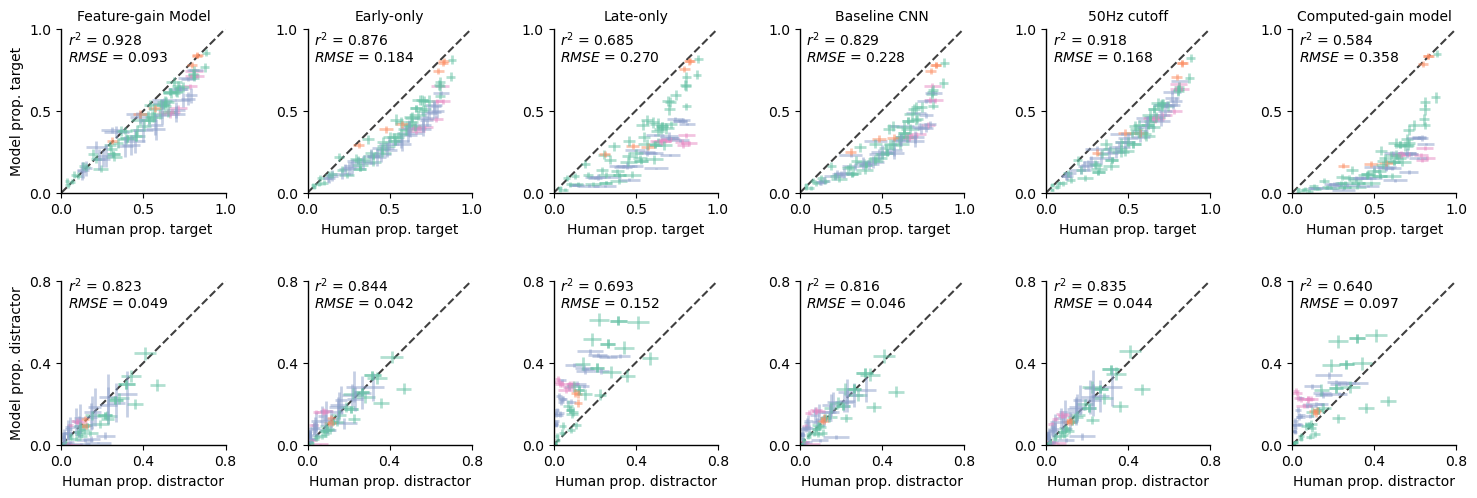

In [ ]:
combined_results['snr_condition_str'] = combined_results['snr'].astype(str) + ' dB ' + combined_results['background_condition']
human_results = combined_results[combined_results.group.str.contains('Human')]
human_results = human_results.sort_values(['snr', 'background_condition'])

model_list = [model for model in combined_results.group.unique() if 'Human' not in model]

model_acc_r = []
model_conf_r = []
model_acc_rmse = []
model_conf_rmse = []

x = y = np.linspace(0,1,5)
fontsize = 10
aspect = 3

sem_order = 2 # 2 for 95% CI, 1 for SEM

fig, axs = plt.subplots(2, len(model_list), 
                        figsize=((aspect * len(model_list)),
                        aspect*2))
acc_axs = axs[0,:]
conf_axs = axs[1,:]

line_width=2
# for ix, group in enumerate(to_plot.group.unique()):
# add dashed line to each subplot 
for i in range(2):
    for j in range(1 + len(model_list)):
        if j != len(model_list):
            axs[i,j].plot(x,y, ls='dashed', color='k', alpha=0.75)


vert_spacing = 0.1 
conf_max_y = 0.8


model_order = util_analysis.model_name_order + ["50Hz cutoff", "Computed-gain model"]
                # 'word_task_half_co_loc_v09_50Hz_cutoff'
            

## Get color palette per experiment 
experiment_colors = [
    'Diotic',
    'Harmonicity',
    'Threshold',
    'Spotlight'
]

# get 4 colors from Set2 palette
cmap = sns.color_palette("Set2", n_colors=4)

color_dict = {experiment:cmap[ix] for  ix,experiment in enumerate(experiment_colors)}
colors = [color_dict[experiment] for experiment in human_results.experiment.values]

model_r2_dict = {}
model_rmse_dict = {}
for ix, model in enumerate(model_order):
    print(model)
    if model == 'Feature-gain Model':
        fba_to_plot = combined_results[combined_results.model.str.contains('main')]# .groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem'], 'confusions':['mean', 'sem']}).reset_index()
        # fba_to_plot.columns = ['snr', 'background_condition', 'accuracy', 'acc_sem', 'confusions', 'conf_sem']
        fba_to_plot['snr_condition_str'] = fba_to_plot['snr'].astype(str) + ' dB ' + fba_to_plot['background_condition']

        fba_to_plot['group'] = 'Feature-gain Model'
        model_results = fba_to_plot.sort_values(['snr', 'background_condition'])
    else:
        model_results = combined_results[combined_results.group == model]
        model_results = model_results.sort_values(['snr', 'background_condition'])


    acc_axs[ix].errorbar(x=human_results.accuracy, y=model_results.accuracy,
                         xerr=human_results.acc_sem * sem_order,
                         yerr=model_results.acc_sem * sem_order, 
                         marker='', alpha=0.5,
                         ecolor=colors,
                         linestyle='', ms=3, elinewidth=line_width,)
    
    conf_axs[ix].errorbar(x=human_results.confusions, y=model_results.confusions,
                          xerr=human_results.conf_sem * sem_order,
                          yerr=model_results.conf_sem * sem_order,
                          marker='', alpha=0.5,
                          ecolor=colors,
                          linestyle='', ms=3, elinewidth=line_width,)
    
    acc_axs[ix].set_title(model, fontsize=fontsize)
    acc_axs[ix].set_xlabel(f"Human prop. target", fontsize=fontsize)
    conf_axs[ix].set_xlabel(f"Human prop. distractor", fontsize=fontsize)

    ## Add stats 
    r, p = stats.pearsonr(human_results.accuracy,  model_results.accuracy)
    # spearman_brown_r = r / np.sqrt(main_model_rho_acc)
    acc_axs[ix].annotate(f"$r^2$ = {r**2:.3f}", (0.04, 0.9), fontsize=fontsize)

    # add to dict 
    model_r2_dict[model] = {}
    model_rmse_dict[model] = {}

    samp_rmse = np.sqrt(np.mean((human_results.accuracy.values - model_results.accuracy.values)**2))
    acc_axs[ix].annotate(f"$RMSE$ = {samp_rmse:.3f}", (0.04, 0.8), fontsize=fontsize)
    model_r2_dict[model]['accuracy'] = r**2
    model_rmse_dict[model]['accuracy'] = samp_rmse

    # conf errors
    r, p = stats.pearsonr(human_results.confusions, model_results.confusions)
    conf_axs[ix].annotate(f"$r^2$ = {r**2:.3f}", (0.032, 0.75), fontsize=fontsize) 
    samp_rmse = np.sqrt(np.mean((human_results.confusions.values - model_results.confusions.values)**2))

    conf_rmse_y = 0.75 - (vert_spacing * conf_max_y)
    conf_axs[ix].annotate(f"$RMSE$ = {samp_rmse:.3f}", (0.032, conf_rmse_y), fontsize=fontsize) # old xy coords (0.25, 0.025)
    model_r2_dict[model]['confusions'] = r**2
    model_rmse_dict[model]['confusions'] = samp_rmse
    

    # set first row x and y limits to 0 1
ticks = np.linspace(0,1,3).round(1)

for ax in acc_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_xlim(0,1)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')

ticks = np.linspace(0,.8,3).round(1)

for ax in conf_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,.8)
    ax.set_xlim(0,.8)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')

acc_axs[0].set_ylabel(f"Model prop. target", fontsize=fontsize)
conf_axs[0].set_ylabel(f"Model prop. distractor", fontsize=fontsize)

sns.despine()
# lines_labels = [ax.get_legend_handles_labels() for ax in [acc_axs[0]]]
# lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(wspace=0.5)


for ax in axs.flat:
    ax.set(aspect='equal')

In [44]:
model_results.experiment.values.shape

(100,)